# Seq Model (Part 3)

In [11]:
import os
import sklearn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import sys
# sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
from nn import nn, io, preprocess
import random

### TO DO : 

1. Use the read_text_file function from io.py to read in the 137 positive Rap1 motif examples.
2. Use the read_fasta_file function from io.py to read in all the negative examples. Note that these sequences are much longer than the positive sequences, so you will need to process them to the same length.
3. Balance your classes using your sample_seq function and explain why you chose the sampling scheme you did.
4. One-hot encode the data using your one_hot_encode_seqs function.
5. Split the data into training and validation sets.
6. Generate an instance of your NeuralNetwork class with an appropriate architecture.
7. Train your neural network on the training data.
8. Plot your training and validation loss by epoch.
9. Report the accuracy of your classifier on your validation dataset.
10. Explain your choice of loss function and hyperparameters.

## 1-2. Load Data

In [12]:
# os.path.join()
pos_seqs = io.read_text_file("./data/rap1-lieb-positives.txt")
neg_seqs = io.read_fasta_file("./data/yeast-upstream-1k-negative.fa")
len(pos_seqs), len(neg_seqs)

(137, 3163)

In [13]:
#creating the labels
pos_rap1_labs = [1]*len(pos_seqs)
neg_rap1_labs = [0]*len(neg_seqs)
labels = pos_rap1_labs + neg_rap1_labs
seqs = pos_seqs + neg_seqs

# 3. Balancing scheme: downsampling

The negative sequences are much longer than the positive ones. To fix this, I'm extracting random snippets of len(positive sequence) from the negative sequences, making sure all sequences are the same size (17 in this case). I'm then downsampling these negative fragments to equal the number of positive examples, creating a 1:1 ratio that prevents the model from becoming biased toward the more frequent genomic background.

In [14]:
#get the target length from positives
target_len = len(pos_seqs[0])

#chopping the long negatives into target_len pieces from which to sample
neg_fragments = []
for long_seq in neg_seqs:
    #taking a random snippet of length L from each long sequence
    if len(long_seq) >= target_len:
        start = random.randint(0, len(long_seq) - target_len)
        neg_fragments.append(long_seq[start : start + target_len])

#combining
all_seqs = pos_seqs + neg_fragments
all_labels = [True] * len(pos_seqs) + [False] * len(neg_fragments)

#balancing them
balanced_seqs, balanced_labels = preprocess.sample_seqs(all_seqs, all_labels)

# 4. One-Hot Encoding

In [15]:
one_hot_seqs = preprocess.one_hot_encode_seqs(balanced_seqs)

# 5. Train/Val splitting

In [16]:
X = np.array(one_hot_seqs)
y = np.array(balanced_labels)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, shuffle= True, random_state=42
)

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")

Training shape: (219, 68)
Validation shape: (55, 68)


# 6. Make your NN

In [21]:
architecture = [{'input_dim': 68, 'output_dim': 16, 'activation': 'relu'}, {'input_dim': 16, 'output_dim': 68, 'activation': 'sigmoid'}]
potential_lrs = [0.001, 0.01, 0.1]
potential_batches = [5, 10, 20]
seed = 42
batch_size = 20
epochs = 1000
loss_function = "bce"


labels = []
nns = []
for lr in potential_lrs:
    for batch in potential_batches:
        labels.append(f"BatchSize_{batch}_LR_{lr}")
        nns.append(nn.NeuralNetwork(architecture, lr, seed, batch, epochs, loss_function))

labels

# seqNN = nn.NeuralNetwork(architecture, lr, seed, batch_size, epochs, loss_function)

['BatchSize_5_LR_0.001',
 'BatchSize_10_LR_0.001',
 'BatchSize_20_LR_0.001',
 'BatchSize_5_LR_0.01',
 'BatchSize_10_LR_0.01',
 'BatchSize_20_LR_0.01',
 'BatchSize_5_LR_0.1',
 'BatchSize_10_LR_0.1',
 'BatchSize_20_LR_0.1']

# 7. Train

In [22]:
trains = []
vals = []
for nn in nns:
    train_losses, val_losses = nn.fit(X_train, y_train, X_val, y_val)
    trains.append(train_losses)
    vals.append(val_losses)

## 8. Plot loss by epoch

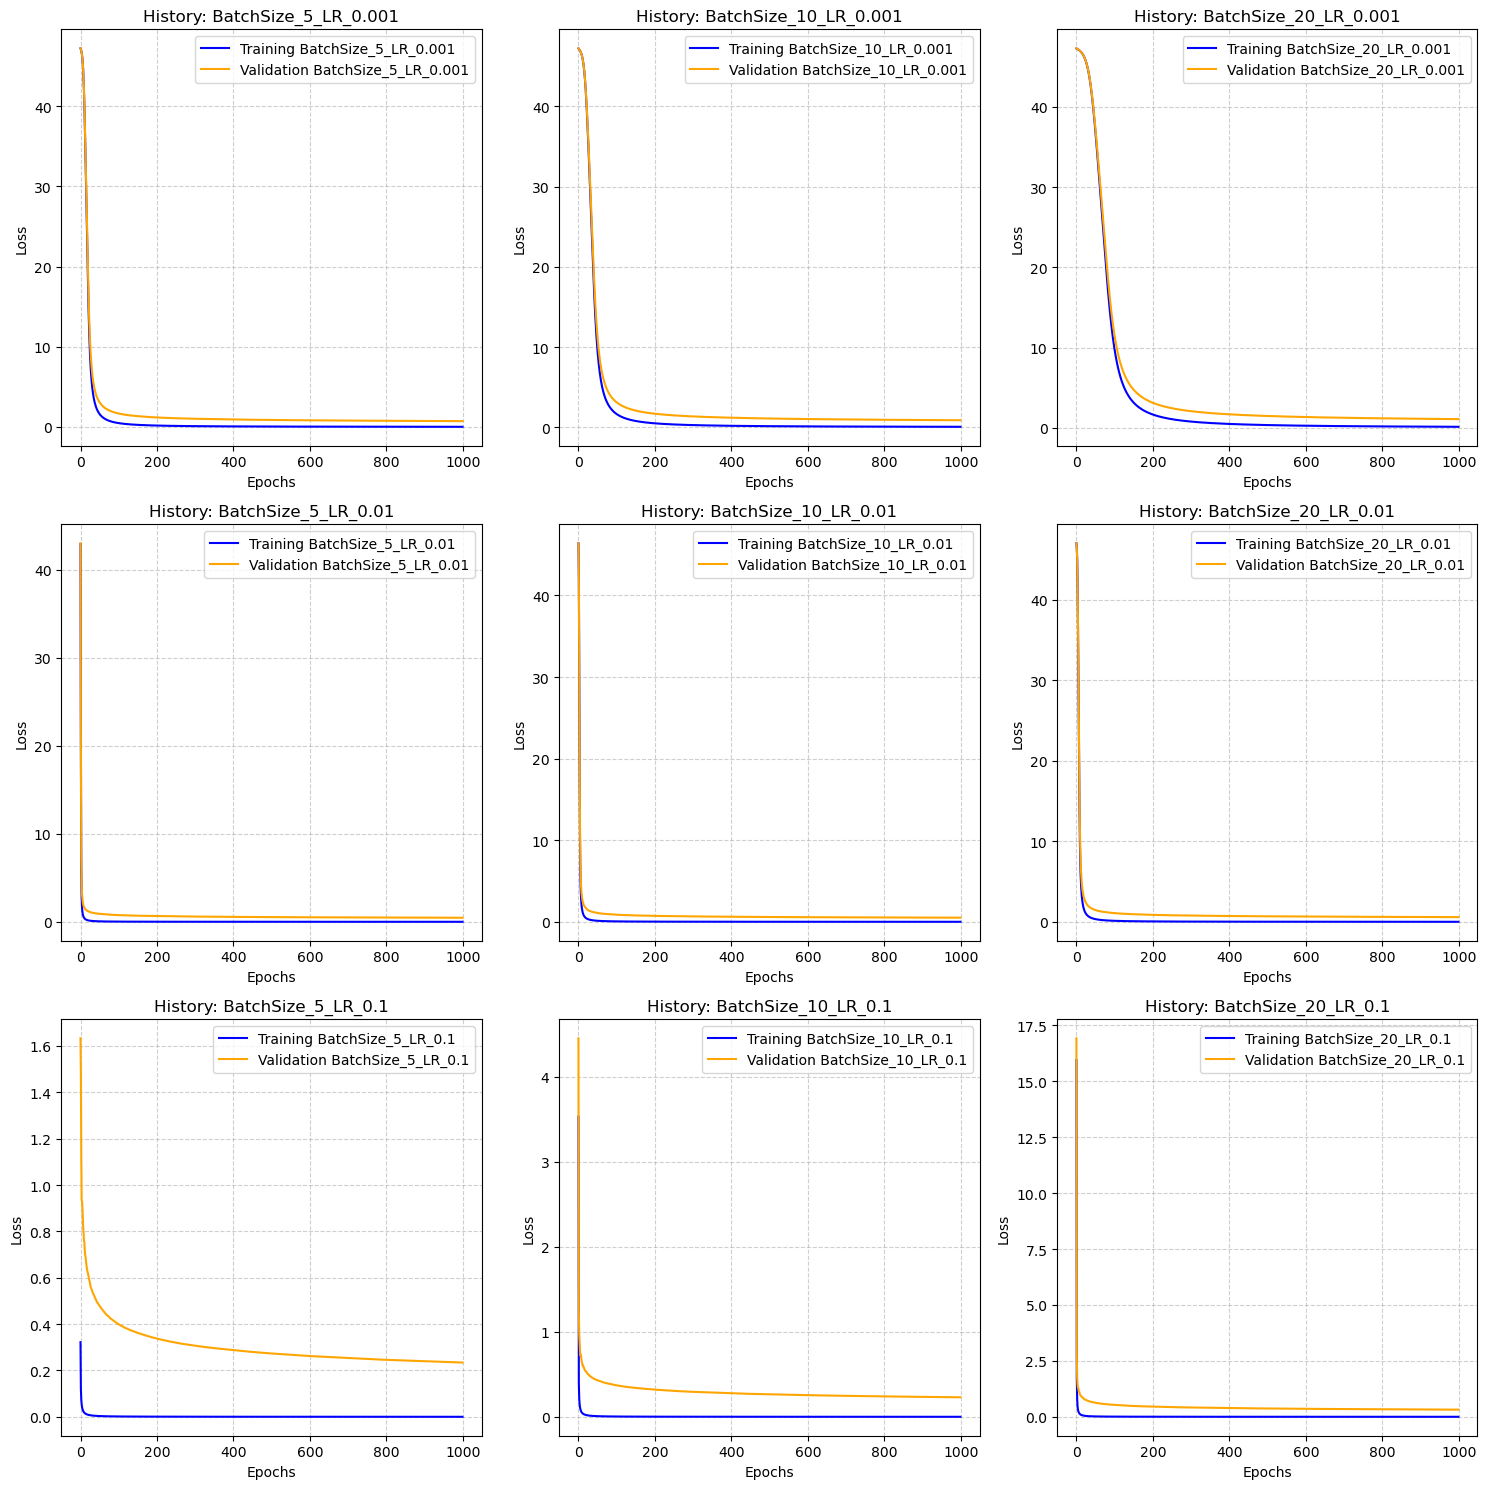

In [ ]:
import math
import matplotlib.pyplot as plt

n_plots = len(labels)
cols = 3
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 5))
axes = axes.flatten() 

for idx, (train, val) in enumerate(zip(trains, vals)):
    ax = axes[idx]
    label = labels[idx]
    
    ax.plot(train, label=f'Training {label}', color='blue')
    ax.plot(val, label=f'Validation {label}', color='orange')
    
    ax.set_title(f'History: {label}', fontsize=12)
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## 9. Accuracy on validation set

In [24]:
for idx, (train, val) in enumerate(zip(trains, vals)):
    avg_val_loss = float(np.mean(val))
    print(labels[idx])
    print(f"My average reconstruction error over the validation set: {avg_val_loss}")

BatchSize_5_LR_0.001
My average reconstruction error over the validation set: 1.911460540973217
BatchSize_10_LR_0.001
My average reconstruction error over the validation set: 3.0536744312191284
BatchSize_20_LR_0.001
My average reconstruction error over the validation set: 5.169053987999587
BatchSize_5_LR_0.01
My average reconstruction error over the validation set: 0.6660902498649366
BatchSize_10_LR_0.01
My average reconstruction error over the validation set: 0.8303651252334714
BatchSize_20_LR_0.01
My average reconstruction error over the validation set: 1.1388421025703201
BatchSize_5_LR_0.1
My average reconstruction error over the validation set: 0.3063523863956424
BatchSize_10_LR_0.1
My average reconstruction error over the validation set: 0.2939376361064917
BatchSize_20_LR_0.1
My average reconstruction error over the validation set: 0.42933098730404884


#### **Final pick: BatchSize_5_LR_0.01 model, with an average reconstruction error of ~0.667**

## 10. Explain hyperparameters & loss function

I went with the same tiling I did in part 2: combined batch sizes of [5, 10, 20] with learning rates of [0.1, 0.01, 0.001]. I'm selecting the best performing model on the validation set, which is the BatchSize_5_LR_0.01 model, with an average reconstruction error of ~0.667.

*I'm aware that by doing so, I might be biasing my model towards the validation set. In a perfect ML problem, I would have also divided the data into a test set that would be the final evaluation; once testing on the test set, there would be no further iteration of hyperparameters or improvement.*

I also chose the loss function Binary Cross Entropy -- if the true label is 1, BCE penalizes the model more heavily as the prediction approaches 0. Also with MSE, if the target is 1 and the model predicts 0, the gradient is flat, making it hard for the model to learn from its mistake. With BCE, if the model is confidently wrong, the gradient is large, forcing the model to correct itself quickly.